0.025692072904006272


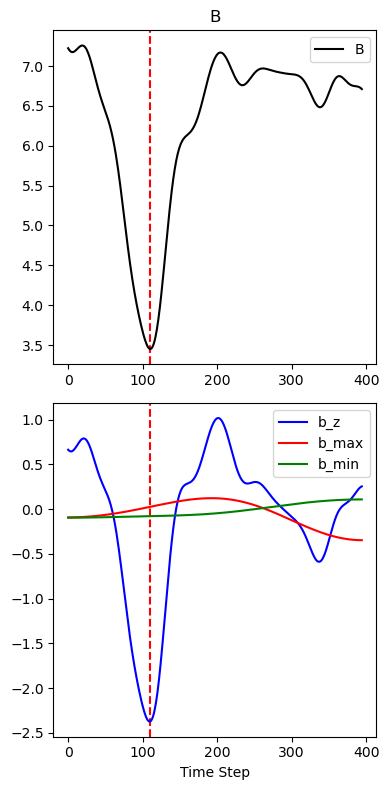

In [5]:
# draw samples
import matplotlib.pyplot as plt
import os 
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import re
from scipy import signal
import numpy as np

def draw_samples(samples_path, cluster, num=None, save=False):
    path = os.path.join(samples_path, cluster, num)
    df = pd.read_parquet(path)
    
    fig, axes = plt.subplots(2, 1, figsize=(4, 8))
    UT = pd.to_datetime(df['UT'], format='%Y-%m-%d %H:%M:%S.%f')
    B = df['B'].values
    b_z = df['b_z'].values
    b_max = df['b_max'].values
    b_min = df['b_min'].values

    def gau(B, b_z, b_max, b_min, sigma, l, r):
        # B = signal.detrend(B)
        # b_z = signal.detrend(b_z)
        # b_max = signal.detrend(b_max)
        # b_min = signal.detrend(b_min)

        b_max = gaussian_filter1d(b_max, sigma=sigma)
        b_min = gaussian_filter1d(b_min, sigma=sigma)
        # b_z = gaussian_filter1d(b_z, sigma=sigma)
        # B = gaussian_filter1d(B, sigma=sigma/5)

        # B[:l] = gaussian_filter1d(B[:l], sigma=sigma)
        # b_z[:l] = gaussian_filter1d(b_z[:l], sigma=sigma)
        # B[r:] = gaussian_filter1d(B[r:], sigma=sigma)
        # b_z[r:] = gaussian_filter1d(b_z[r:], sigma=sigma)

        # 截取到r
        # b_z, b_max, b_min, B = b_z[:r], b_max[:r], b_min[:r], B[:r]

        # 旋转拉到接近水平
        # B[r:] = [0.04 * (idx - r) + B[idx] for idx in range(r, len(B))]
        # B[:l] = [-0.01 * (idx - l) + B[idx] for idx in range(l)]

        # # 左边补50个点，右边补100个点，用边界值
        # pad_num_l = 50
        # pad_num_r = 100
        # B = np.pad(B, (pad_num_l, pad_num_r), 'edge')
        # b_z = np.pad(b_z, (pad_num_l, pad_num_r), 'edge')
        # b_max = np.pad(b_max, (pad_num_l, pad_num_r), 'edge')
        # b_min = np.pad(b_min, (pad_num_l, pad_num_r), 'edge')
        # # 再高斯平滑
        # B = gaussian_filter1d(B, sigma=sigma/5)
        # b_z = gaussian_filter1d(b_z, sigma=sigma/5)

        # 整体向右平移1个点，左侧用边界值补齐
        def shift_list(lst, n):
            if len(lst) == 0:
                return lst
            length = len(lst)
            if n > 0:
                padding = [lst[0]] * n
                if n >= length:
                    return padding[:length]
                return padding + list(lst[:length - n])
            elif n < 0:
                n_abs = abs(n)
                padding = [lst[-1]] * n_abs
                if n_abs >= length:
                    return padding[:length]
                return list(lst[n_abs:]) + padding
            else:
                return lst
        
        # shift = -1
        # b_max = shift_list(b_max, shift)
        
        return B, b_z, b_max, b_min

    B, b_z, b_max, b_min = gau(B, b_z, b_max, b_min, sigma=80, l=103, r=170)

    if cluster == 'sheet' or cluster == 'hole':
        min_idx = np.argmin(B)
        axes[0].axvline(min_idx, color='red', linestyle='--')
        axes[1].axvline(min_idx, color='red', linestyle='--')
        # 输出B最小时，b_max的值
        print(b_max[min_idx])
    if cluster == 'soliton':
        max_idx = np.argmax(B)
        axes[0].axvline(max_idx, color='red', linestyle='--')
        axes[1].axvline(max_idx, color='red', linestyle='--')

    axes[0].plot(B, label='B', color='black')
    axes[1].plot(b_z, label='b_z', color='blue')
    axes[1].plot(b_max, label='b_max', color='red')
    axes[1].plot(b_min, label='b_min', color='green')
    axes[0].legend()
    axes[1].legend()
    axes[0].set_title('B')
    axes[1].set_xlabel('Time Step')
    plt.tight_layout()
    os.makedirs(os.path.join('../samples_clean', cluster), exist_ok=True)
    df = pd.DataFrame({'UT': UT, 'B': B, 'b_z': b_z, 'b_max': b_max, 'b_min': b_min})
    if save:
        df.to_parquet(os.path.join('..\\samples_clean', cluster, num), index=False)

workspace = '..\\'
draw_samples(os.path.join(workspace, 'samples'), cluster='hole', num='5.parquet', save=True)

In [7]:
import pandas as pd
# temp = pd.read_parquet(f"../trainset_20240101-0130/41053.parquet")
temp = pd.read_parquet(f"../trainset_20240101-0130/32267.parquet")
# temp = pd.read_parquet(f"../trainset_20240101-0130/37446.parquet")
print(temp.head()) 

                          UT         B       b_z     b_max     b_min
0 2024-01-19 17:13:37.617951  7.223196  0.663523 -0.790991 -0.564748
1 2024-01-19 17:13:37.649201  7.207509  0.654818 -0.784445 -0.580694
2 2024-01-19 17:13:37.680451  7.194898  0.648784 -0.774990 -0.593122
3 2024-01-19 17:13:37.711700  7.185391  0.645442 -0.762580 -0.601949
4 2024-01-19 17:13:37.742950  7.178950  0.644752 -0.747201 -0.607122


d:\Anaconda\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


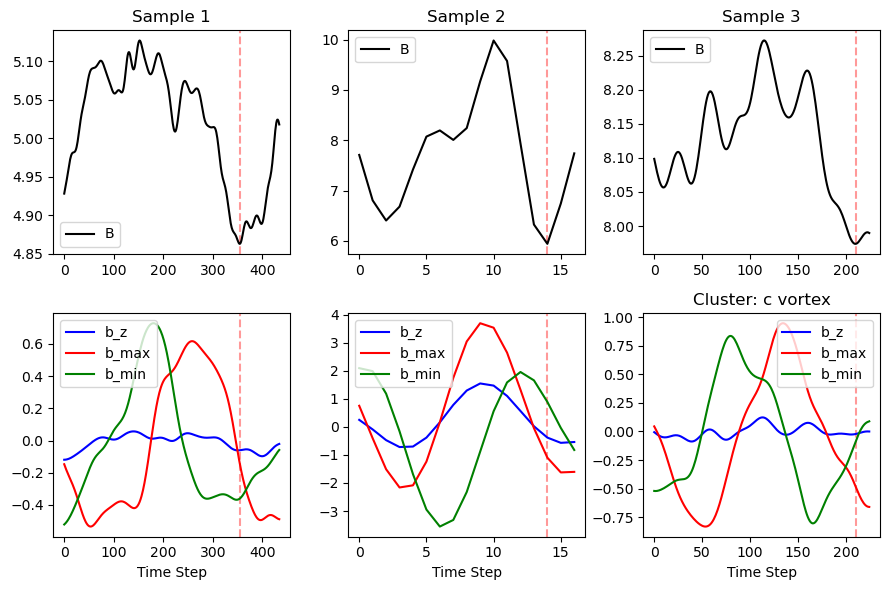

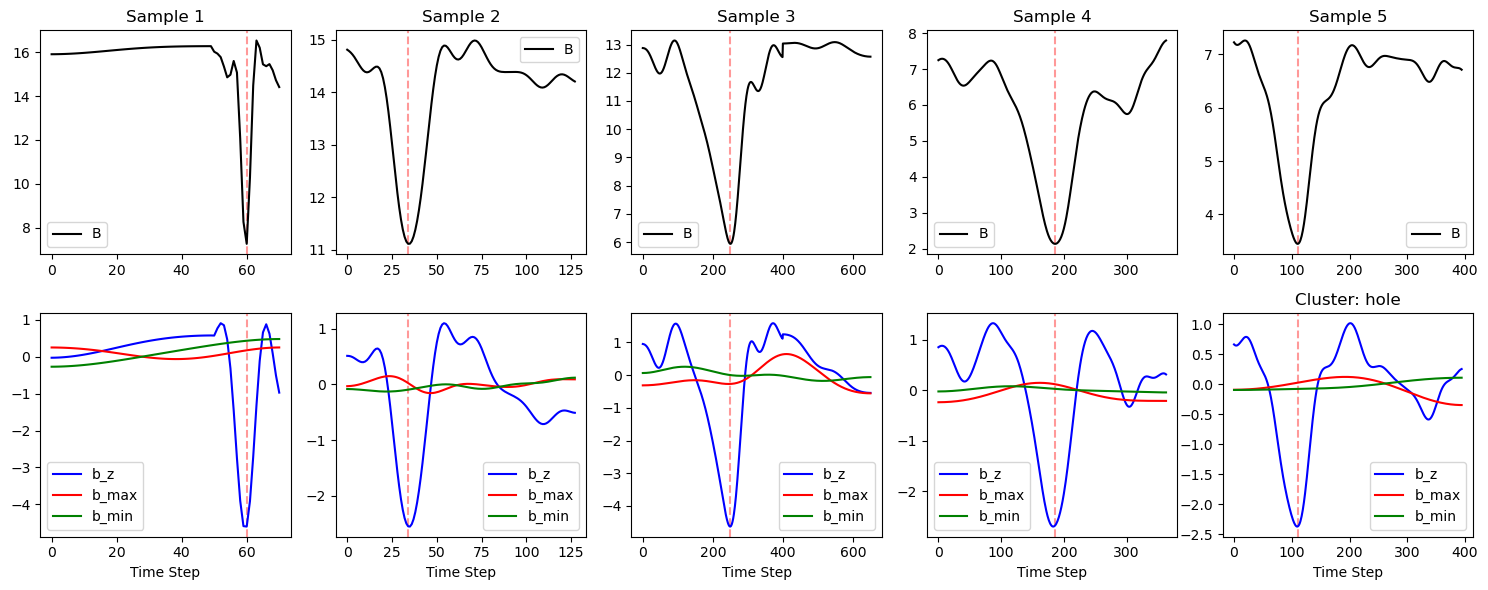

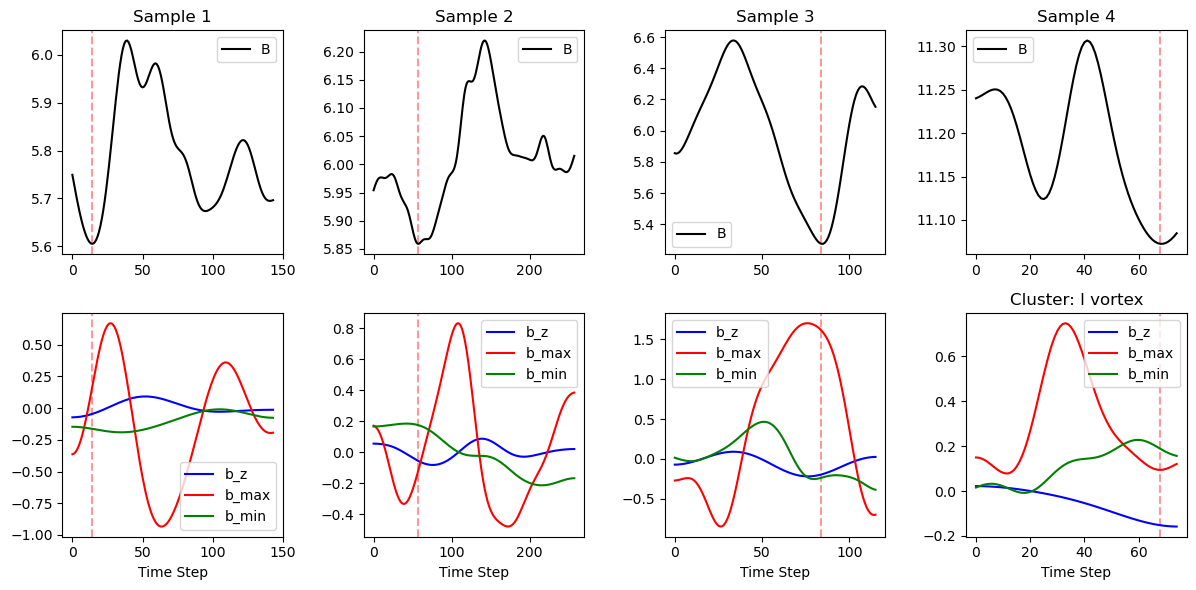

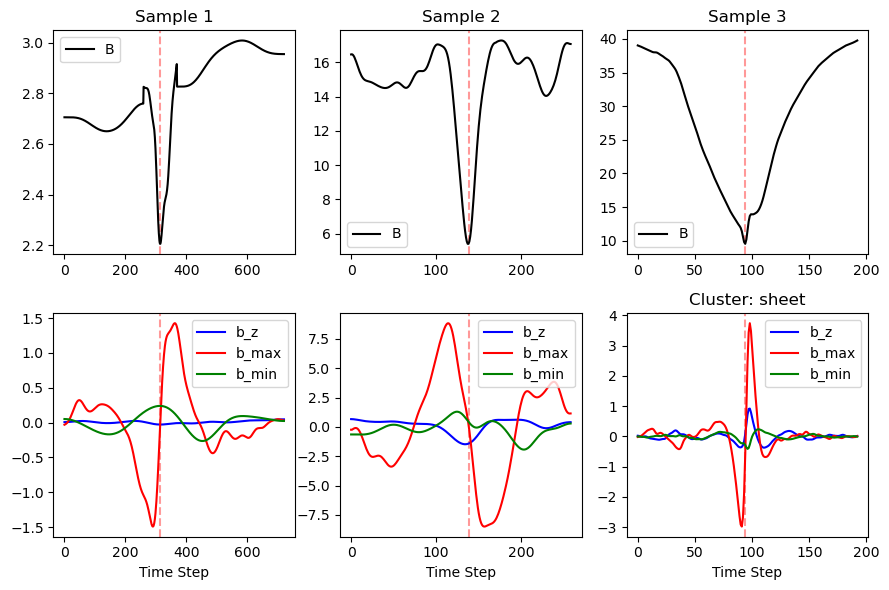

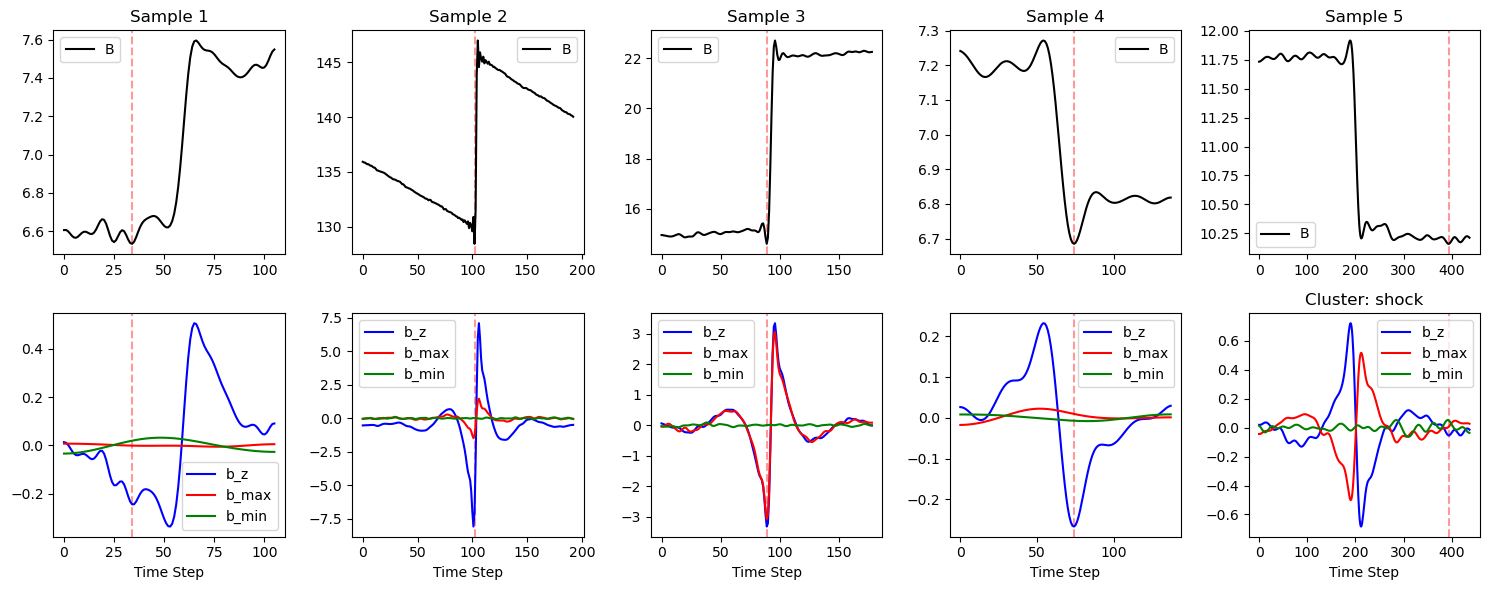

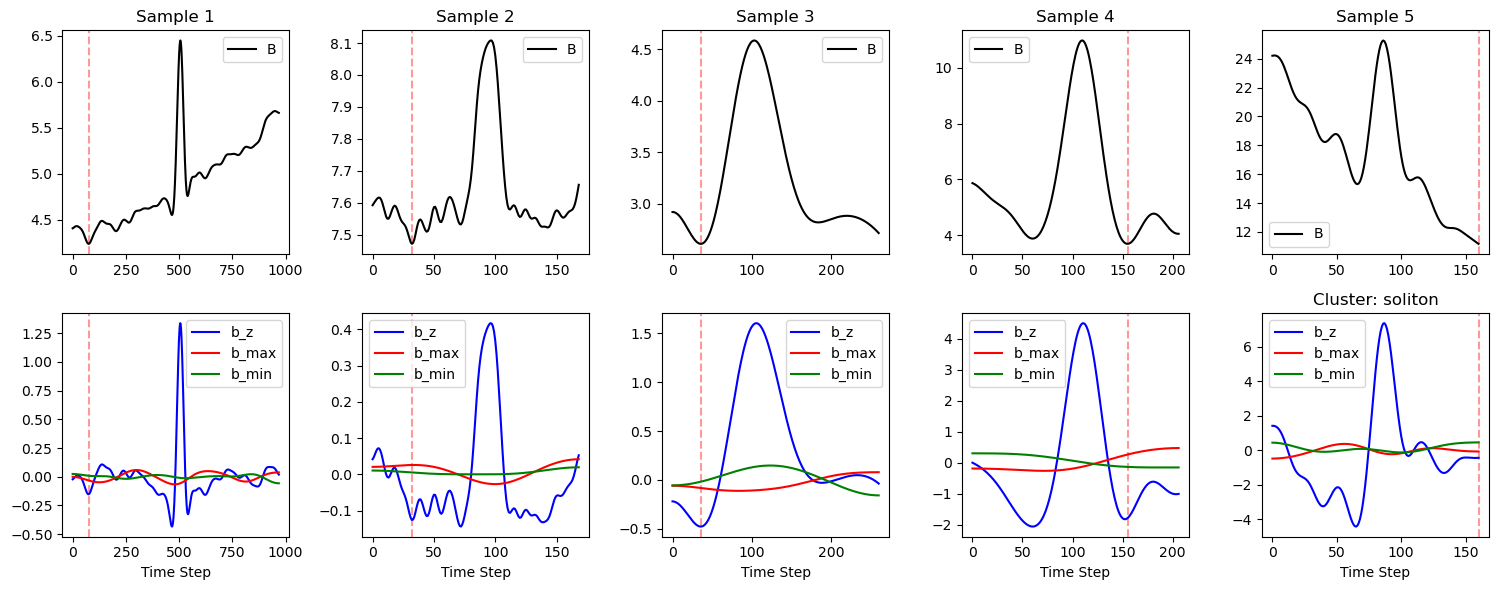

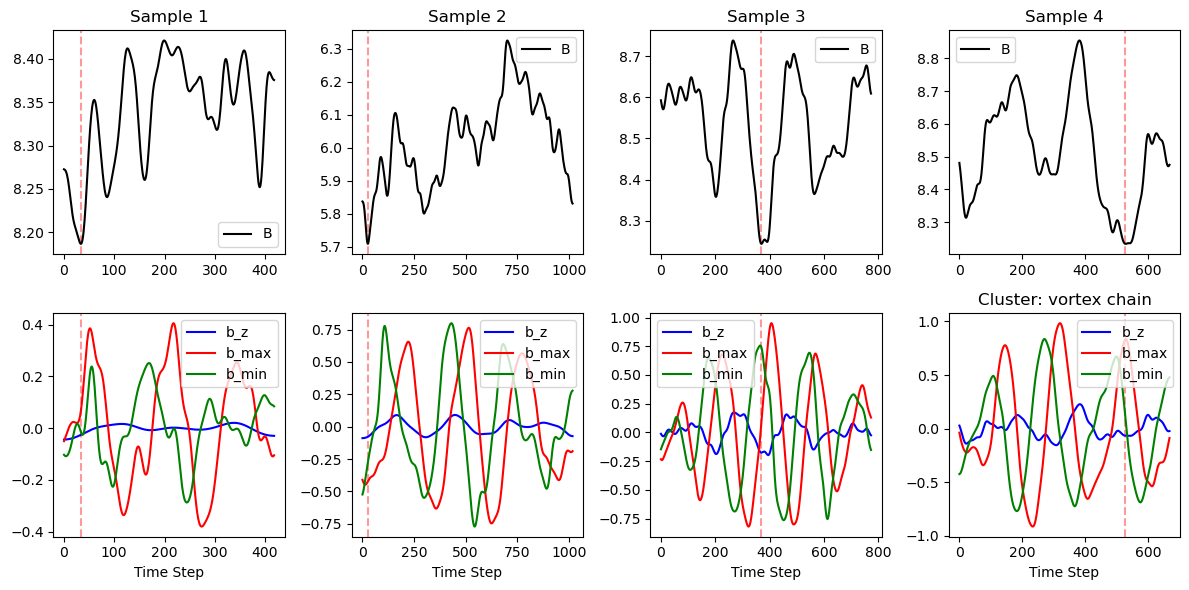

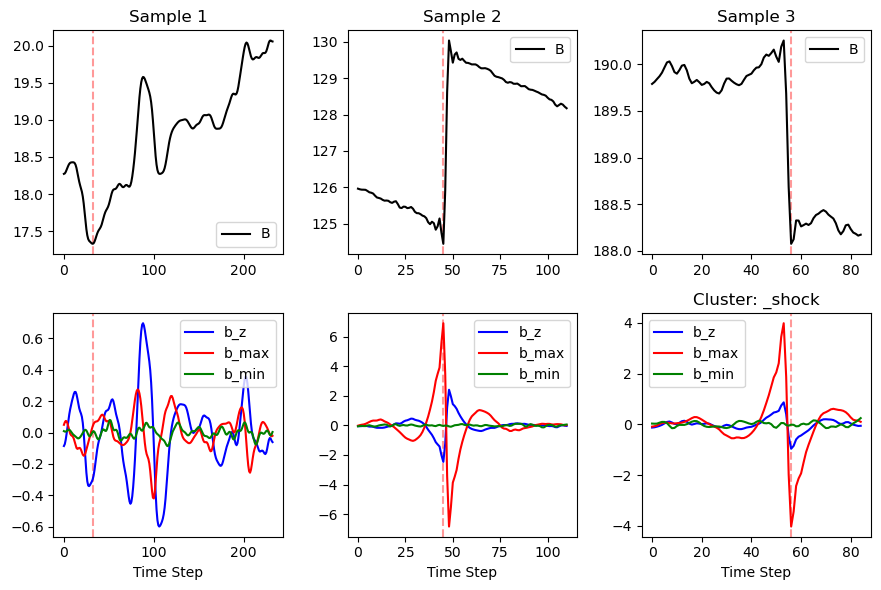

In [1]:
# draw samples_clean
import matplotlib.pyplot as plt
import os 
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import re
import numpy as np

def interpolate_seq(seq, target_len):
                """
                线性插值序列到指定长度
                """
                x_old = np.arange(len(seq))
                x_new = np.linspace(0, len(seq)-1, target_len)
                return np.interp(x_new, x_old, seq)

def draw_samples(samples_path, cluster):
    path = os.path.join(samples_path, cluster)
    files = [f for f in os.listdir(path) if f.endswith('.parquet')]
    def get_file_num(filename):
        match = re.search(r'\d+', filename)
        return int(match.group()) if match else 0
    files = sorted(files, key=get_file_num)
    df_list = []
    for f in files:
        file_path = os.path.join(path, f)
        df = pd.read_parquet(file_path)
        df_list.append(df)
    
    num_samples = len(df_list)
    if num_samples > 1:
        fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
        for i, df in enumerate(df_list):
            B = df['B'].values
            b_z = df['b_z'].values
            b_max = df['b_max'].values
            b_min = df['b_min'].values
            
            # B, b_z, b_max, b_min = interpolate_seq(B, 300), interpolate_seq(b_z, 300), interpolate_seq(b_max, 300), interpolate_seq(b_min, 300)

            min_idx = np.argmin(B)
            axes[0, i].axvline(min_idx, color='red', linestyle='--', alpha=0.4)
            axes[1, i].axvline(min_idx, color='red', linestyle='--', alpha=0.4)

            axes[0, i].plot(B, label='B', color='black')
            axes[1, i].plot(b_z, label='b_z', color='blue')
            axes[1, i].plot(b_max, label='b_max', color='red')
            axes[1, i].plot(b_min, label='b_min', color='green')
            axes[0, i].legend()
            axes[1, i].legend()
            axes[0, i].set_title(f'Sample {i+1}')
            axes[1, i].set_xlabel('Time Step')
    elif num_samples == 1:
        B = df['B'].values
        b_z = df['b_z'].values
        b_max = df['b_max'].values
        b_min = df['b_min'].values

        # B, b_z, b_max, b_min = interpolate_seq(B, 300), interpolate_seq(b_z, 300), interpolate_seq(b_max, 300), interpolate_seq(b_min, 300)
        
        fig, axes = plt.subplots(2, 1, figsize=(3, 6))

        min_idx = np.argmin(B)
        axes[0].axvline(min_idx, color='red', linestyle='--', alpha=0.4)
        axes[1].axvline(min_idx, color='red', linestyle='--', alpha=0.4)

        axes[0].plot(B, label='B', color='black')
        axes[1].plot(b_z, label='b_z', color='blue')
        axes[1].plot(b_max, label='b_max', color='red')
        axes[1].plot(b_min, label='b_min', color='green')
        axes[0].legend()
        axes[1].legend()
        axes[0].set_title('B')
        axes[1].set_xlabel('Time Step')

    plt.title(f'Cluster: {cluster}')
    plt.tight_layout()

workspace = '..\\'
draw_samples(os.path.join(workspace, 'samples_clean'), cluster='c vortex')
draw_samples(os.path.join(workspace, 'samples_clean'), cluster='hole')
draw_samples(os.path.join(workspace, 'samples_clean'), cluster='l vortex')
draw_samples(os.path.join(workspace, 'samples_clean'), cluster='sheet')
draw_samples(os.path.join(workspace, 'samples_clean'), cluster='shock')
draw_samples(os.path.join(workspace, 'samples_clean'), cluster='soliton')
draw_samples(os.path.join(workspace, 'samples_clean'), cluster='vortex chain')

# draw_samples(os.path.join(workspace, 'samples_clean'), cluster='_sheet')
draw_samples(os.path.join(workspace, 'samples_clean'), cluster='_shock')


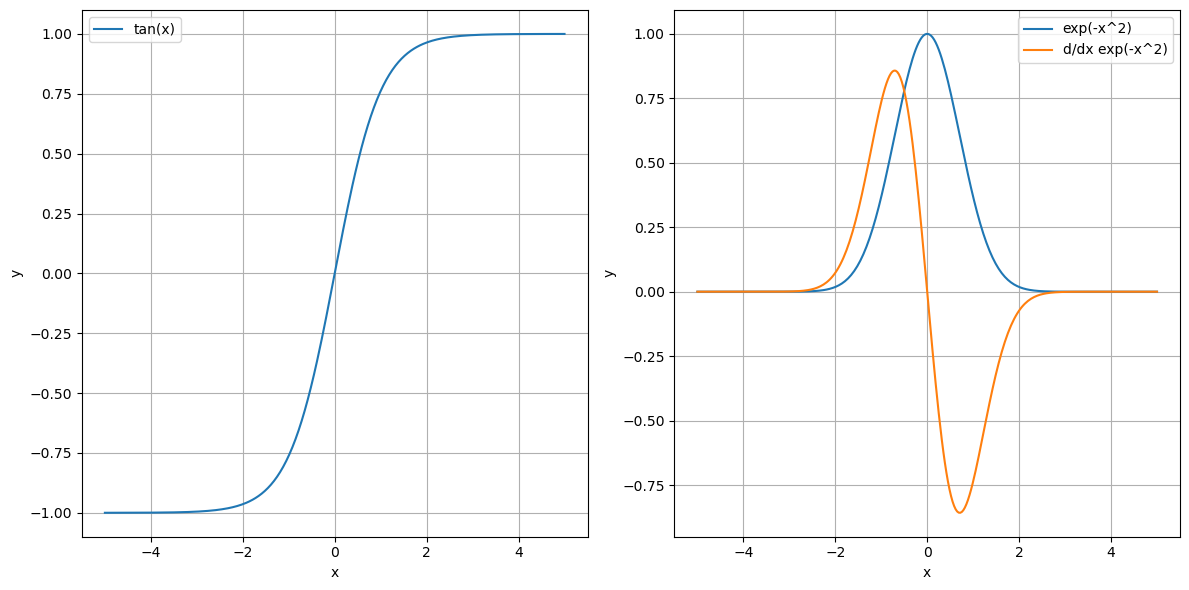

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# 生成300个采样点
x = np.linspace(-5, 5, 300)
tanh_x = np.tanh(x)

# 计算高斯函数及其一阶导数
# 高斯函数: f(x) = exp(-x^2)
gaussian = np.exp(-x**2)
gaussian_derivative = -2 * x * np.exp(-x**2)  # 高斯函数的一阶导数

# 创建图形
plt.figure(figsize=(12, 6))

# 绘制正切函数及其导数
plt.subplot(1, 2, 1)
plt.plot(x, tanh_x, label='tan(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# 绘制高斯函数及其导数
plt.subplot(1, 2, 2)
plt.plot(x, gaussian, label='exp(-x^2)')
plt.plot(x, gaussian_derivative, label="d/dx exp(-x^2)")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# 调整布局
plt.tight_layout()
plt.show()

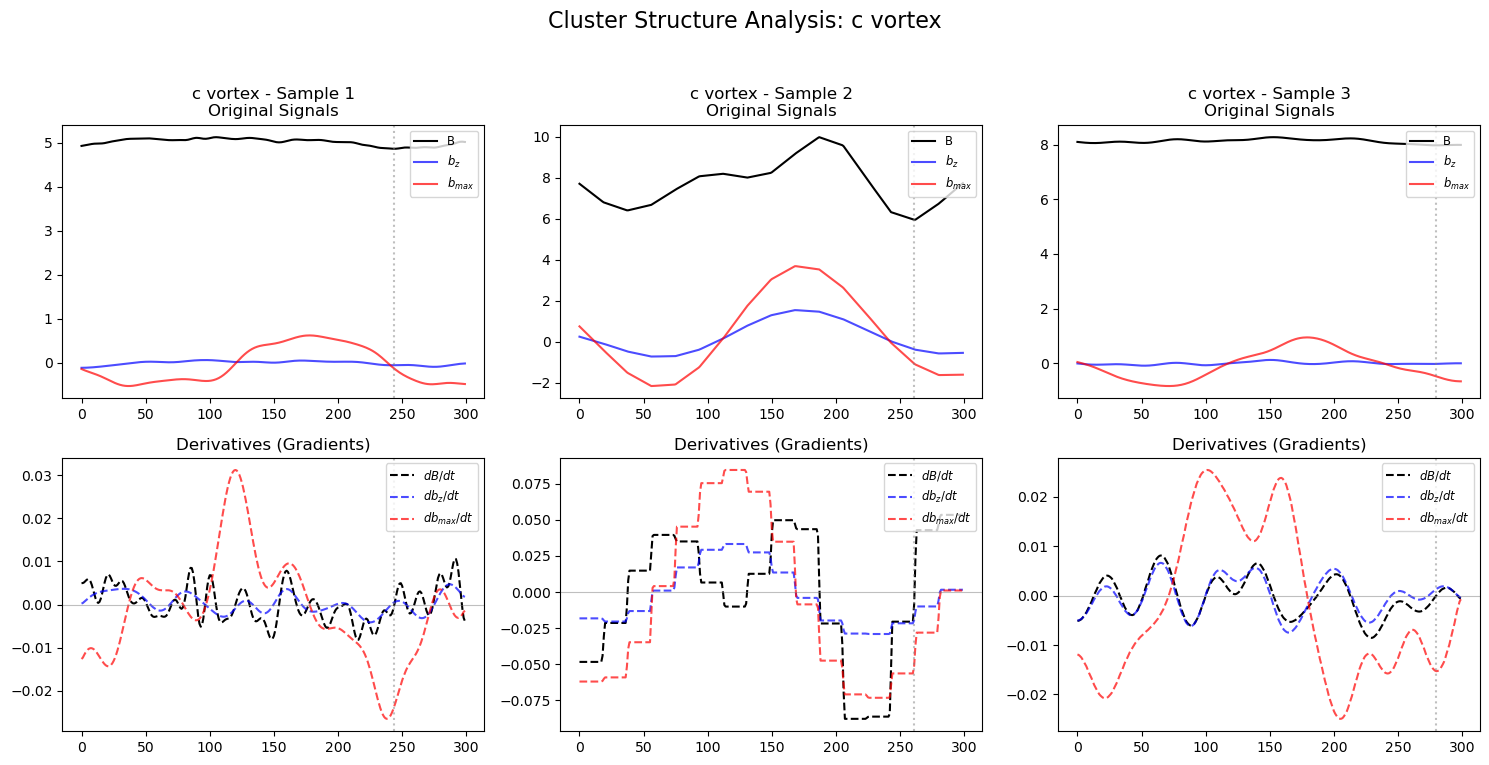

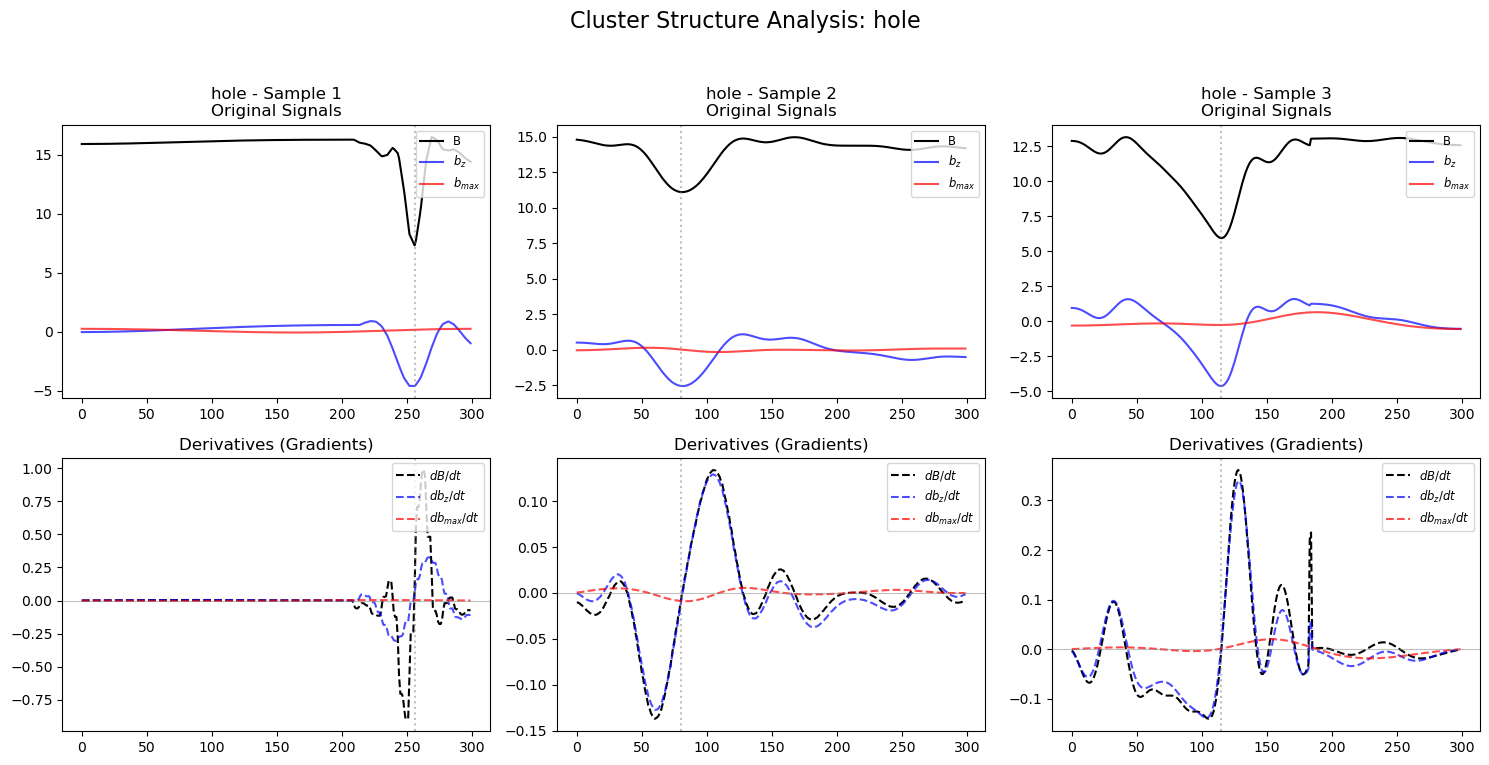

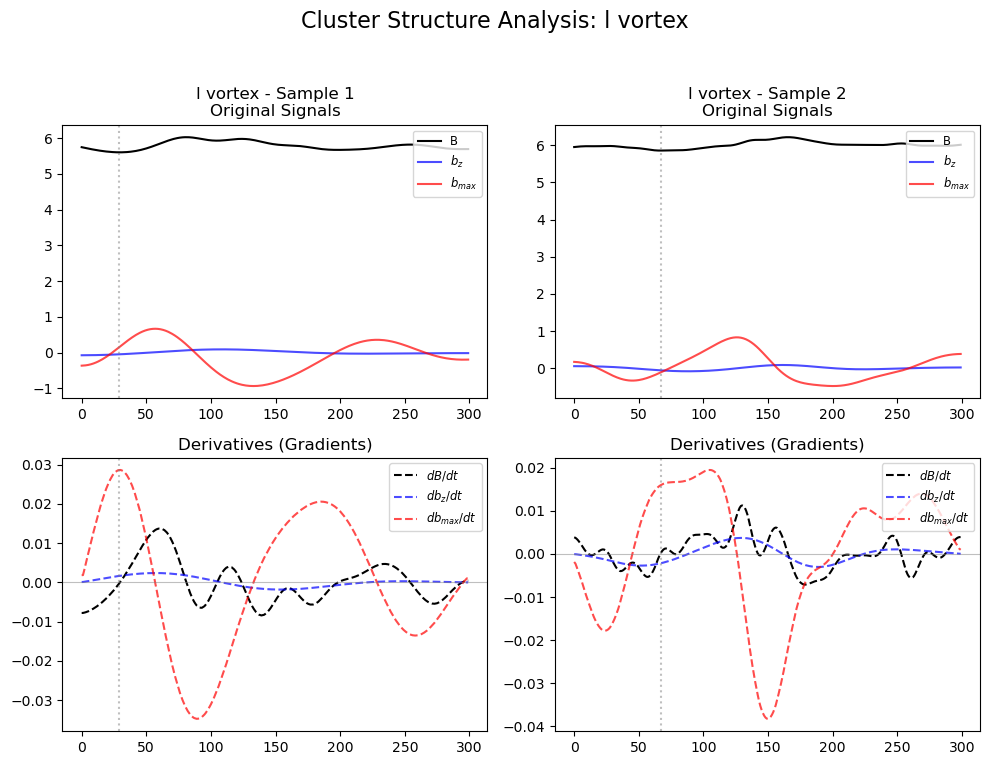

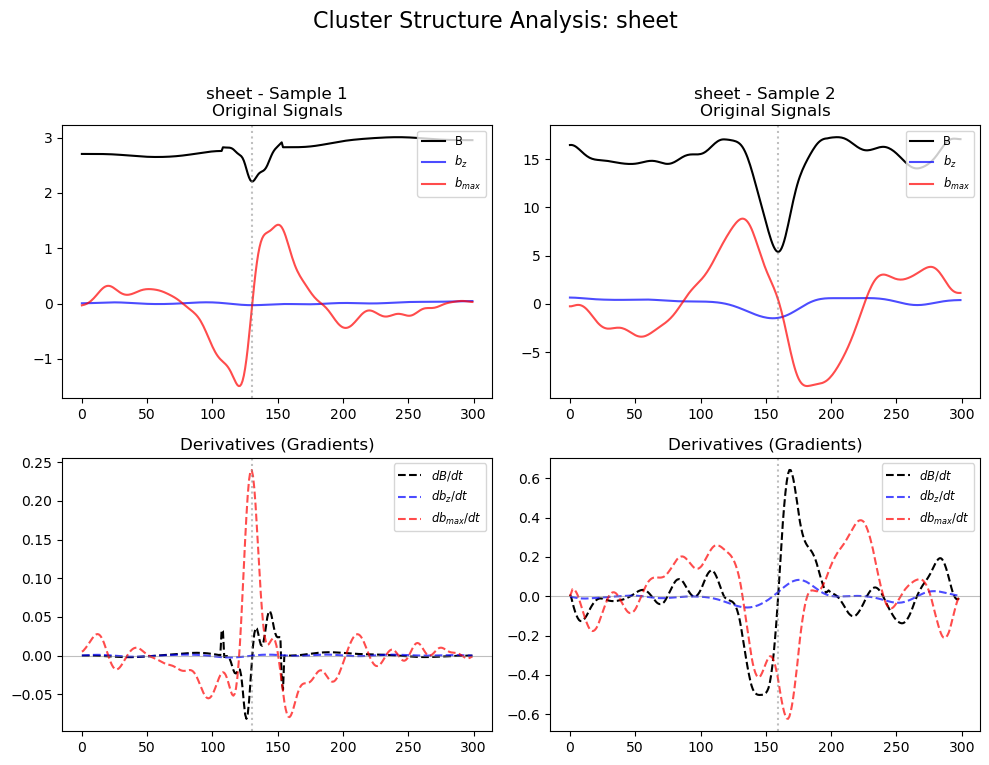

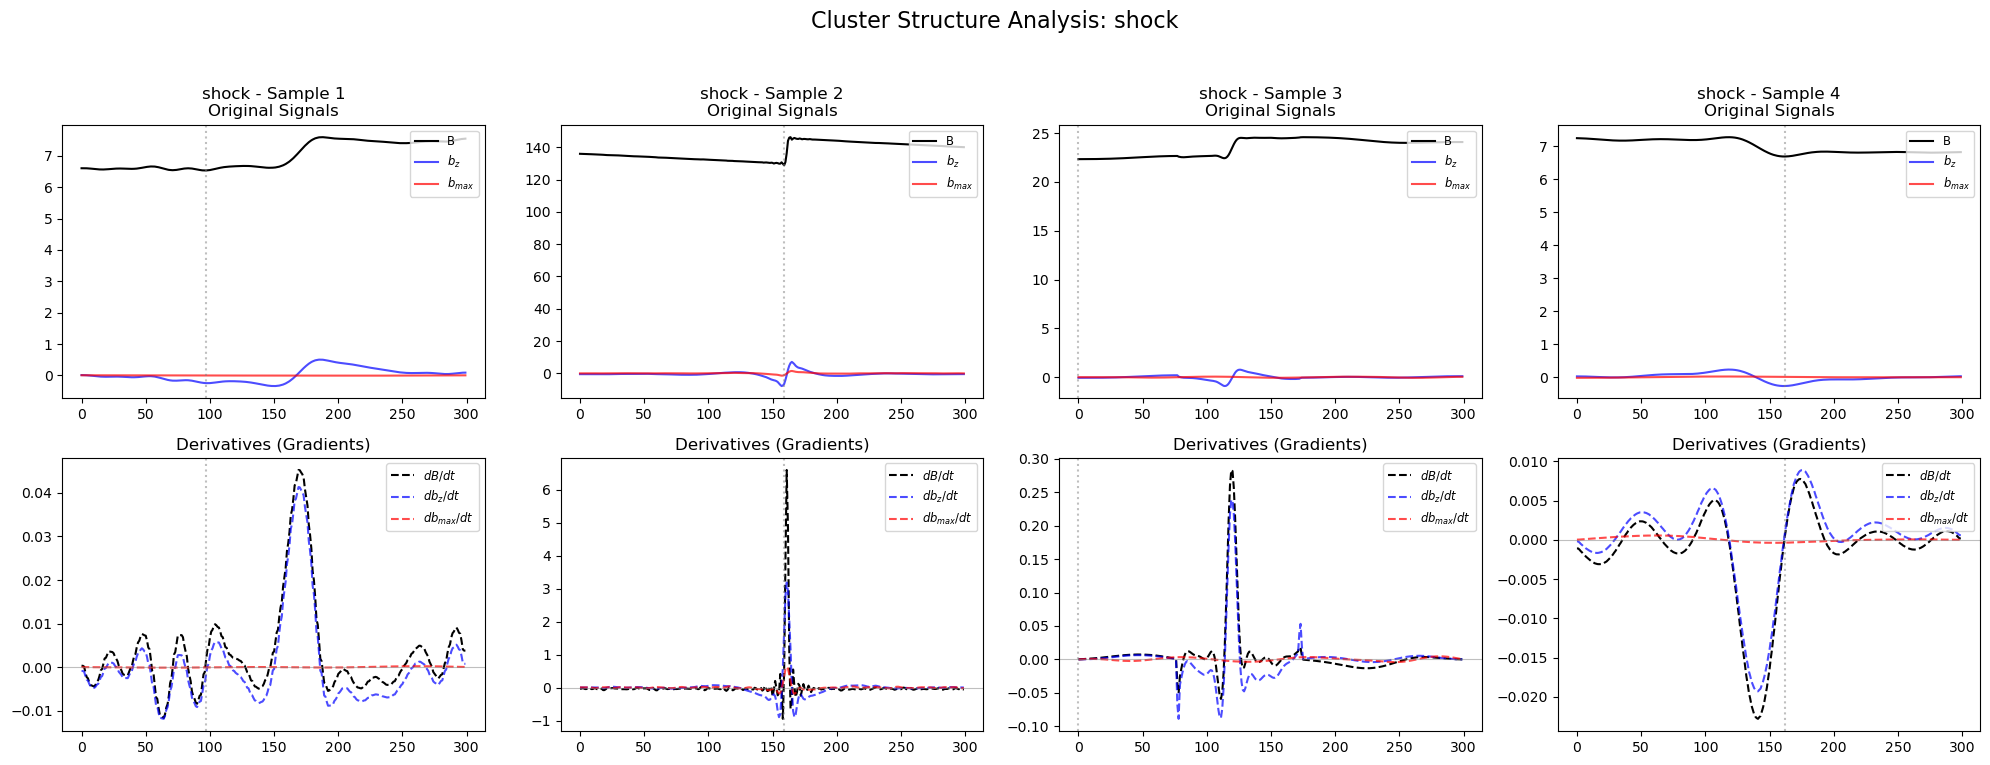

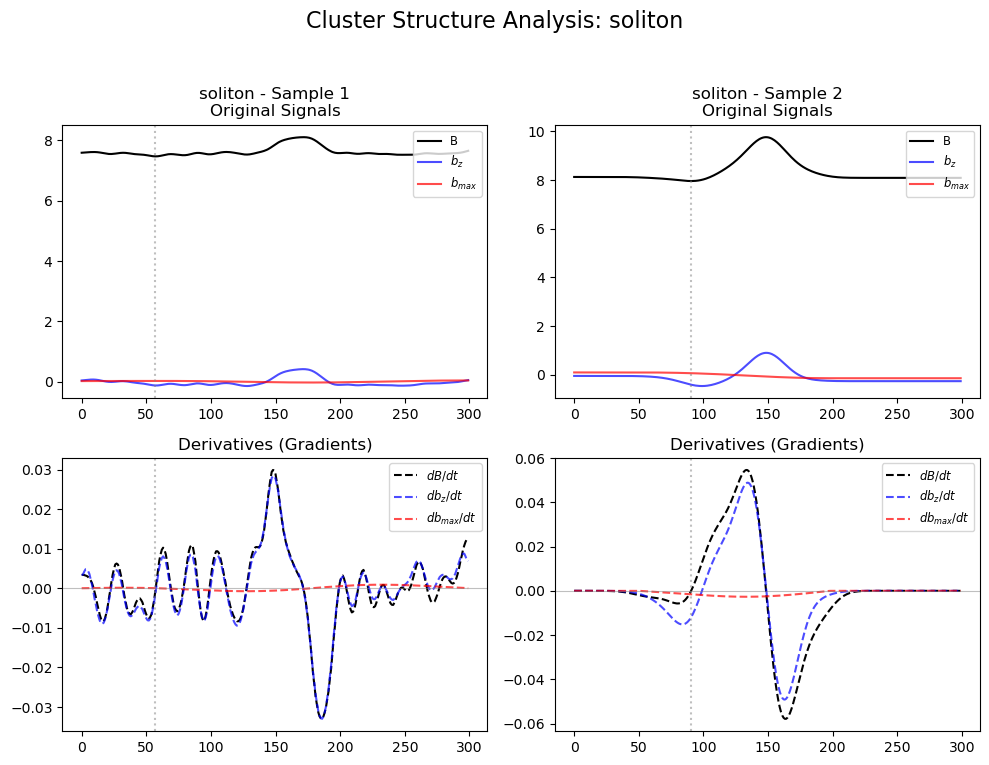

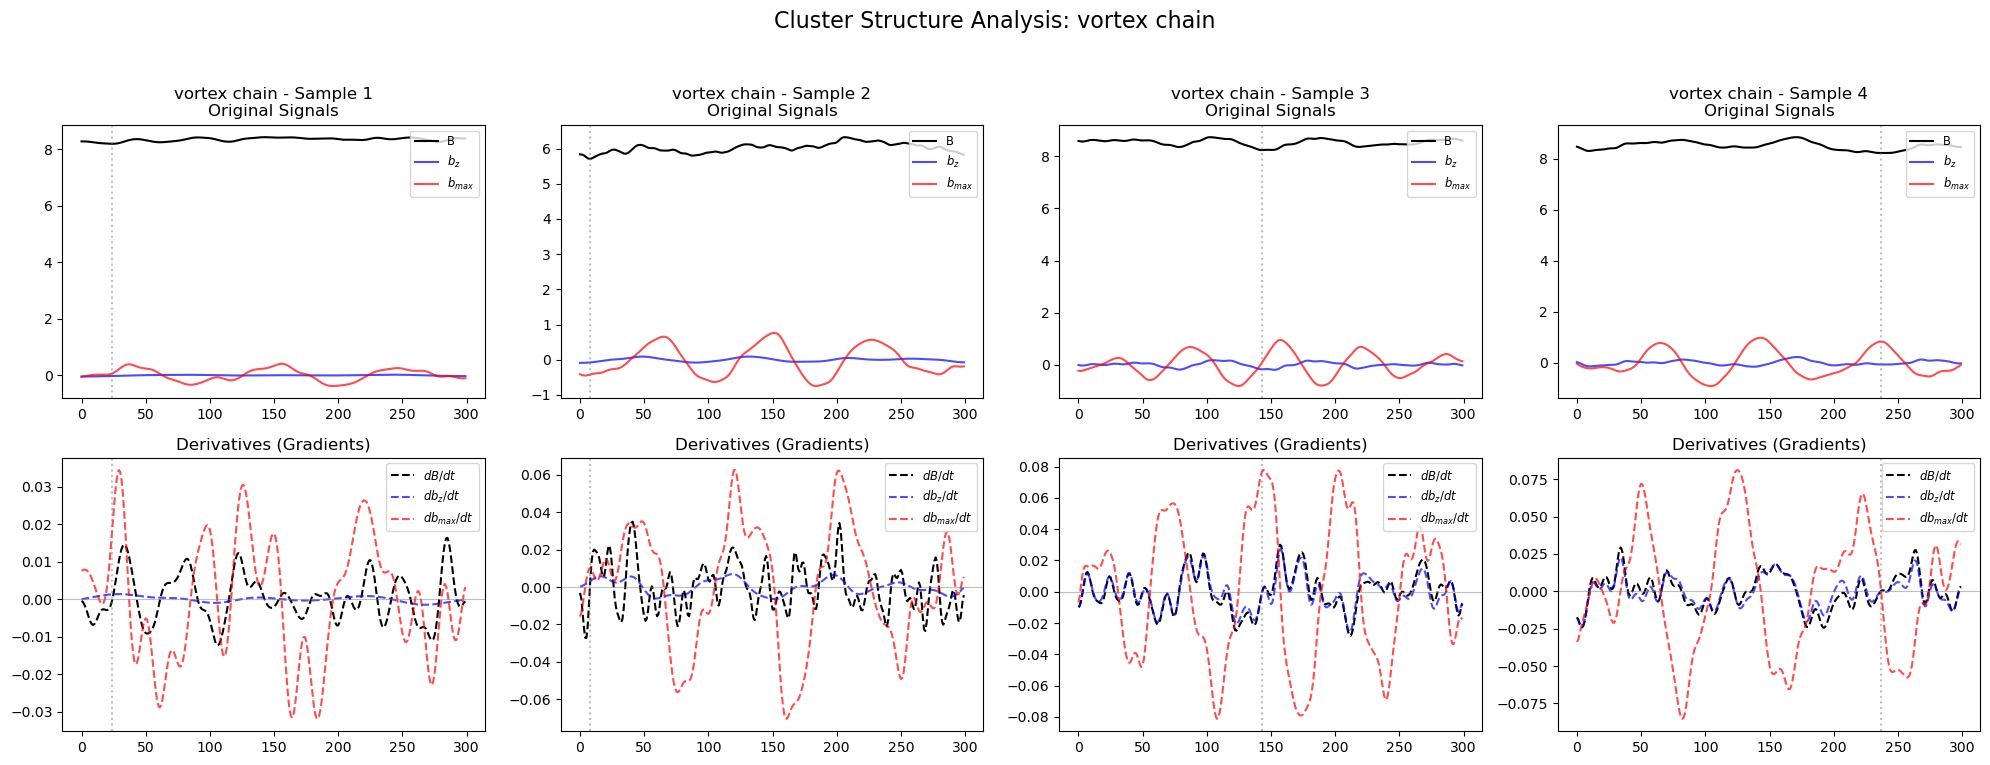

In [16]:
import matplotlib.pyplot as plt
import os 
import pandas as pd
import numpy as np
import re

def interpolate_seq(seq, target_len):
    """线性插值序列到指定长度"""
    x_old = np.arange(len(seq))
    x_new = np.linspace(0, len(seq)-1, target_len)
    return np.interp(x_new, x_old, seq)

def draw_samples_with_derivatives(samples_path, cluster):
    path = os.path.join(samples_path, cluster)
    if not os.path.exists(path):
        print(f"Skipping {cluster}: Path not found.")
        return

    files = [f for f in os.listdir(path) if f.endswith('.parquet')]
    def get_file_num(filename):
        match = re.search(r'\d+', filename)
        return int(match.group()) if match else 0
    files = sorted(files, key=get_file_num)
    
    df_list = []
    for f in files:
        file_path = os.path.join(path, f)
        df = pd.read_parquet(file_path)
        df_list.append(df)
    
    num_samples = len(df_list)
    if num_samples == 0: return

    # 创建画布：第一行原始波形，第二行导数波形
    fig, axes = plt.subplots(2, num_samples, figsize=(5*num_samples, 8), squeeze=False)

    for i, df in enumerate(df_list):
        # 1. 提取并插值
        B = interpolate_seq(df['B'].values, 300)
        b_z = interpolate_seq(df['b_z'].values, 300)
        b_max = interpolate_seq(df['b_max'].values, 300)
        
        # 2. 计算数值梯度 (使用中心差分)
        # grad 能够反映：间断点 -> 脉冲；斜率翻转 -> 极值
        dB = np.gradient(B)
        db_z = np.gradient(b_z)
        db_max = np.gradient(b_max)

        # 3. 绘制第一行：原始信号
        axes[0, i].plot(B, label='B', color='black', linewidth=1.5)
        axes[0, i].plot(b_z, label='$b_z$', color='blue', alpha=0.7)
        axes[0, i].plot(b_max, label='$b_{max}$', color='red', alpha=0.7)
        axes[0, i].set_title(f'{cluster} - Sample {i+1}\nOriginal Signals')
        axes[0, i].legend(loc='upper right', fontsize='small')
        
        # 4. 绘制第二行：导数信号
        axes[1, i].plot(dB, label='$dB/dt$', color='black', linestyle='--')
        axes[1, i].plot(db_z, label='$db_z/dt$', color='blue', linestyle='--', alpha=0.7)
        axes[1, i].plot(db_max, label='$db_{max}/dt$', color='red', linestyle='--', alpha=0.7)
        axes[1, i].axhline(0, color='gray', linewidth=0.8, alpha=0.5) # 零水平线
        axes[1, i].set_title('Derivatives (Gradients)')
        axes[1, i].legend(loc='upper right', fontsize='small')
        
        # 标注 B 最小点，观察导数在该位置的表现
        min_idx = np.argmin(B)
        axes[0, i].axvline(min_idx, color='gray', linestyle=':', alpha=0.5)
        axes[1, i].axvline(min_idx, color='gray', linestyle=':', alpha=0.5)

    plt.suptitle(f'Cluster Structure Analysis: {cluster}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 运行绘图 ---
workspace = '..\\'
samples_base_path = os.path.join(workspace, 'samples_clean')
clusters = ['c vortex', 'hole', 'l vortex', 'sheet', 'shock', 'soliton', 'vortex chain', '_sheet']

for target_cluster in clusters:
    draw_samples_with_derivatives(samples_base_path, cluster=target_cluster)

## 范本的特征表

In [8]:
import torch

def extract_physical_features_batch(data_batch, device):
    # data_batch: [N, 300, 4]
    B = data_batch[:, :, 0]
    bz = data_batch[:, :, 1]
    bmax = data_batch[:, :, 2]
    bmin = data_batch[:, :, 3]
    N = data_batch.size(0)
    batch_indices = torch.arange(N, device=device)
    
    # =========================================================================
    # 0. 基础导数预计算 (统一计算，方便后续提取)
    # =========================================================================
    dot_B = torch.zeros_like(B)
    dot_B[:, :-1] = torch.abs(B[:, 1:] - B[:, :-1])
    dot_B[:, -1] = dot_B[:, -2]
    
    dot_bz = torch.zeros_like(bz)
    dot_bz[:, :-1] = torch.abs(bz[:, 1:] - bz[:, :-1])
    dot_bz[:, -1] = dot_bz[:, -2]
    
    dot_bmax = torch.zeros_like(bmax)
    dot_bmax[:, :-1] = torch.abs(bmax[:, 1:] - bmax[:, :-1])
    dot_bmax[:, -1] = dot_bmax[:, -2]

    # 1. 核心门控指标：压缩性指标 (决定后续特征是否激活)
    bz_sq_max = torch.max(bz**2, dim=1)[0]
    bperp_sq_max = torch.max(bmax**2 + bmin**2, dim=1)[0]
    comp_index = torch.sqrt(bz_sq_max / (bperp_sq_max + 1e-6))
    
    # 定义物理门控掩码 (仅保留阿尔芬结构的硬门控)
    mask_alfven = comp_index < 1.0     # 阿尔芬结构门控
    mask_comp = comp_index > 0.5     # 压缩性结构门控

    def get_abs_skewness(x):
        """计算序列的绝对偏度：E[(x-mu)^3] / sigma^3"""
        mu = torch.mean(x, dim=1, keepdim=True)
        sigma = torch.std(x, dim=1, keepdim=True)
        # 计算三阶标准矩
        skew = torch.mean(((x - mu) / (sigma + 1e-6))**3, dim=1)
        return torch.abs(skew)

    # =========================================================================
    # A. 阿尔芬结构专属判据 (保留 mask_alfven 门控)
    # =========================================================================
    
    # (2) 极化比: max(|b_min|) / max(|b_max|)
    max_abs_bmin = torch.max(torch.abs(bmin), dim=1)[0]
    max_abs_bmax = torch.max(torch.abs(bmax), dim=1)[0]
    raw_pol_ratio = max_abs_bmin / (max_abs_bmax + 1e-6)
    pol_ratio = torch.where(mask_alfven, raw_pol_ratio, torch.zeros_like(raw_pol_ratio))
    
    # (4) b_max 和 b_min 的最大互相关性
    def get_max_corr_pair(x, y):
        N_pts = x.size(1)
        x_norm = (x - x.mean(dim=1, keepdim=True)) 
        y_norm = (y - y.mean(dim=1, keepdim=True))
        pad_size = N_pts * 2
        X_freq = torch.fft.rfft(x_norm, n=pad_size, dim=1)
        Y_freq = torch.fft.rfft(y_norm, n=pad_size, dim=1)
        corr_freq = X_freq * torch.conj(Y_freq)
        cross_corr = torch.fft.irfft(corr_freq, n=pad_size, dim=1)
        x_energy = torch.sqrt(torch.sum(x_norm**2, dim=1) + 1e-8)
        y_energy = torch.sqrt(torch.sum(y_norm**2, dim=1) + 1e-8)
        max_corr = torch.max(torch.abs(cross_corr), dim=1)[0]
        return max_corr / (x_energy * y_energy + 1e-8)
    raw_corr_bmax_bmin = get_max_corr_pair(bmax, bmin)
    # 增加双重条件：极化比>0.2 且 属于阿尔芬结构门控
    condition_corr = (pol_ratio > 0.2) & mask_alfven
    corr_bmax_bmin = torch.where(condition_corr, raw_corr_bmax_bmin, torch.zeros_like(raw_corr_bmax_bmin))
    
    # (5) b_max 的自相关相位
    import torch.nn.functional as F
    def get_generalized_freq(x, device):
        N = x.size(1)
        # 1. 去均值标准化
        x_norm = x - x.mean(dim=1, keepdim=True)
        # 2. 计算自相关
        pad_size = N * 2
        X_freq = torch.fft.rfft(x_norm, n=pad_size, dim=1)
        autocorr = torch.fft.irfft(X_freq * torch.conj(X_freq), n=pad_size, dim=1)[:, :N]
        autocorr = autocorr / (autocorr[:, 0:1] + 1e-8)
        # 3. 寻找所有“极大值点” (Local Maxima)
        # 通过比较相邻点找到所有波峰
        is_max = (autocorr[:, 1:-1] > autocorr[:, :-2]) & (autocorr[:, 1:-1] > autocorr[:, 2:])
        # 4. 阈值筛选 + 第一个显著峰
        # 找“第一个”相关性超过 0.4 且具有显著性的峰
        # 如果没有任何峰超过阈值，它就是单周期 (freq=1)
        freq_est = torch.ones(x.size(0), device=device) # 默认频率为 1
        for i in range(x.size(0)):
            # 找到该样本所有的极大值索引
            peak_indices = torch.where(is_max[i])[0] + 1 
            # 过滤掉靠近原点（Lag < 20）的干扰点
            valid_peaks = peak_indices[peak_indices > 20]
            if len(valid_peaks) > 0:
                # 在这些峰里，找到相关系数最高的那个
                best_peak_idx = valid_peaks[torch.argmax(autocorr[i, valid_peaks])]
                best_corr_val = autocorr[i, best_peak_idx]
                # 如果这个最强峰的相关性足够高（ > 0.4），则承认它
                if best_corr_val > 0.4:
                    freq_est[i] = N / best_peak_idx.float()
        return freq_est
    dom_freq = get_generalized_freq(bmax, device)
    dom_freq = torch.where(mask_alfven, dom_freq, torch.zeros_like(dom_freq))

    
    # (9) B最小时，dot_bmax 凸起的程度和 b_max 的大小
    def calc_sheet_reversal_criterion(B_full, b_max, search_range=100):
        """
        B_full: [Batch, Length] - 总磁场强度 B
        b_max:  [Batch, Length] - 主翻转分量
        search_range: 向两侧搜索极值的最大距离
        """
        batch_size, seq_len = B_full.shape
        device = B_full.device
        # 1. 找到 B 全局最小点索引
        idx_min_B = torch.argmin(B_full, dim=1)
        # 2. 检查中心窗口 (+/- 10) 是否发生变号
        range_tensor = torch.arange(seq_len, device=device).unsqueeze(0)
        center_mask = (range_tensor >= (idx_min_B.unsqueeze(1) - 10)) & \
                      (range_tensor <= (idx_min_B.unsqueeze(1) + 10))
        signs = torch.sign(b_max)
        win_signs = torch.where(center_mask, signs, signs[torch.arange(batch_size), idx_min_B].unsqueeze(1))
        has_flip = (torch.max(win_signs, dim=1).values != torch.min(win_signs, dim=1).values)
        left_extrema_val = torch.zeros(batch_size, device=device)
        right_extrema_val = torch.zeros(batch_size, device=device)
        # 3. 寻找向外延伸的第一个局部极值
        for i in range(batch_size):
            if not has_flip[i]: continue
            center = idx_min_B[i]
            # --- 右侧搜索：从 center 向右 ---
            r_end = min(seq_len, center + search_range + 1)
            r_segment = b_max[i, center : r_end]
            if r_segment.numel() > 1:
                # 计算相邻点的差值 (类似导数)
                diffs_r = torch.diff(r_segment)
                signs_r = torch.sign(diffs_r)
                # 寻找导数符号发生变化的位置 (即出现极值或平缓区)
                changes_r = torch.nonzero(signs_r[:-1] != signs_r[1:]).squeeze(1)
                if len(changes_r) > 0:
                    # +1 是因为 diff 会使得索引偏移，取变号后的那个点作为极值点
                    right_extrema_val[i] = r_segment[changes_r[0] + 1]
                else:
                    # 如果在 search_range 内单调递增/递减没有极值，则取边界点
                    right_extrema_val[i] = r_segment[-1]
            elif r_segment.numel() == 1:
                right_extrema_val[i] = r_segment[0]
            # --- 左侧搜索：从 center 向左 ---
            l_start = max(0, center - search_range)
            l_segment = b_max[i, l_start : center + 1]
            if l_segment.numel() > 1:
                # 关键：将左侧切片反转，使其物理意义变为“从 center 向左延伸”
                rev_l_segment = torch.flip(l_segment, dims=[0])
                diffs_l = torch.diff(rev_l_segment)
                signs_l = torch.sign(diffs_l)
                changes_l = torch.nonzero(signs_l[:-1] != signs_l[1:]).squeeze(1)
                
                if len(changes_l) > 0:
                    left_extrema_val[i] = rev_l_segment[changes_l[0] + 1]
                else:
                    left_extrema_val[i] = rev_l_segment[-1]
            elif l_segment.numel() == 1:
                left_extrema_val[i] = l_segment[0]
        # 最终判定：变号且两翼（第一个局部）极值绝对值均 > 0.5
        is_current_sheet = has_flip & (torch.abs(left_extrema_val) > 0.5) & (torch.abs(right_extrema_val) > 0.5)
        # 返回得分：如果是电流片，得分 = 1.0 - |b_max在B最小时的值|
        val_at_min = b_max[batch_indices, idx_min_B]
        score = 1.0 - torch.abs(val_at_min)
        score = torch.where(is_current_sheet, score, torch.zeros_like(score))
        return score
    idx_min_B = torch.argmin(B, dim=1)
    peakiness_dot_bmax = dot_bmax[batch_indices, idx_min_B]
    peakiness_dot_bmax = torch.where(mask_alfven, peakiness_dot_bmax, torch.zeros_like(peakiness_dot_bmax))
    b_max_flipscore = calc_sheet_reversal_criterion(B, bmax, search_range=100)
    b_max_flipscore = torch.where(mask_alfven, b_max_flipscore, torch.zeros_like(b_max_flipscore))

    # （16）b_max梯度的偏度
    diff_bmax = bmax[:, 1:] - bmax[:, :-1]
    abs_skew_grad_bmax = get_abs_skewness(diff_bmax)
    abs_skew_grad_bmax = torch.where(mask_alfven, abs_skew_grad_bmax, torch.zeros_like(abs_skew_grad_bmax))


    # =========================================================================
    # B. 压缩性结构专属判据 (移除 mask_comp 硬截断，保留物理连续性)
    # =========================================================================

    # (3) b_z和B 扰动凹陷或凸起程度
    idx_max_bz = torch.argmax(torch.abs(bz), dim=1)
    bz_dip = bz[batch_indices, idx_max_bz]
    idx_max_B = torch.argmax(torch.abs(B), dim=1)
    B_dip = B[batch_indices, idx_max_B]
    B_dip = torch.where(mask_comp, B_dip, torch.zeros_like(B_dip))

    # (6) 激波指标: b_z 斜率(差分)绝对值的最大值
    max_grad_bz = torch.max(torch.abs(bz[:, 1:] - bz[:, :-1]), dim=1)[0]

    # (8) 激波判据：b_z最大值的绝对值减最小值的绝对值
    b_z_max_ = torch.max(bz, dim=1)[0]
    b_z_min_ = torch.min(bz, dim=1)[0]
    R_jump = 1 - (torch.abs(b_z_max_) - torch.abs(b_z_min_)) # 越接近1说明越跳变
    R_jump = torch.where(mask_comp, R_jump, torch.zeros_like(R_jump))

    # (10) dot_B 的全局峰度 (Kurtosis)
    mean_dot_B = torch.mean(dot_B, dim=1, keepdim=True)
    std_dot_B = torch.std(dot_B, dim=1, keepdim=True)
    kurt_dot_B = torch.mean(((dot_B - mean_dot_B) / (std_dot_B + 1e-6))**4, dim=1) / 10.0
    kurt_dot_B = torch.where(mask_comp, kurt_dot_B, torch.zeros_like(kurt_dot_B))

    # (11) 在 dot_bz 最大值附近 (±10个点) 的积分 (局部能量聚集度)
    idx_max_dot_bz = torch.argmax(dot_bz, dim=1)
    offsets = torch.arange(-10, 11, device=device).view(1, -1) # [1, 21]
    window_idx_dot_bz = torch.clamp(idx_max_dot_bz.view(-1, 1) + offsets, 0, 299)
    int_dot_bz_window = torch.gather(dot_bz, 1, window_idx_dot_bz).sum(dim=1)
    int_dot_bz_window = torch.where(mask_comp, int_dot_bz_window, torch.zeros_like(int_dot_bz_window))

    # (12) dot_bz 的全局峰度 (Kurtosis)
    mean_dot_bz = torch.mean(dot_bz, dim=1, keepdim=True)
    std_dot_bz = torch.std(dot_bz, dim=1, keepdim=True)
    kurt_dot_bz = torch.mean(((dot_bz - mean_dot_bz) / (std_dot_bz + 1e-6))**4, dim=1) / 10.0
    kurt_dot_bz = torch.where(mask_comp, kurt_dot_bz, torch.zeros_like(kurt_dot_bz))

    # (13) b_z和b_max穿过 ±0.5 的次数 (反映震荡结构的复杂程度)
    def calc_criterion_16(bz, threshold=0.5):
        """
        bz: [Batch, Length] 的张量
        计算 bz 穿过 threshold 和 -threshold 的总次数并除以 4
        """
        # 1. 计算穿过 +0.5 的次数
        # 当相邻两个点的符号不同时，代表发生了一次穿越
        cross_plus = torch.diff((bz > threshold).int(), dim=1).abs().sum(dim=1)
        # 2. 计算穿过 -0.5 的次数
        cross_minus = torch.diff((bz < -threshold).int(), dim=1).abs().sum(dim=1)
        # 3. 求和并归一化
        # 对于一个标准的双极性脉冲 (0 -> 1 -> -1 -> 0):
        # 穿过 0.5 两次 (上一、下一)，穿过 -0.5 两次 (下一、上一)，总计 4 次。4/4 = 1.0
        complexity_index = (cross_plus + cross_minus).float() / 4.0
        score = torch.exp(-(complexity_index-1)**2 / 0.3 **2) # 距离标准值1越远，得分越低
        return score
    complexity_index_bz = calc_criterion_16(bz)
    complexity_index_bmax = calc_criterion_16(bmax)

    # (14) B 场与 tanh 模板的最大相关性
    def get_max_corr_template(x, y_template):
        """
        计算 batch x 与单个模板 y_template 之间的最大互相关性 (位移无关)
        """
        N_pts = x.size(1)
        # 模板扩展到 batch 大小
        y = y_template.expand(x.size(0), -1)
        x_norm = (x - x.mean(dim=1, keepdim=True)) 
        y_norm = (y - y.mean(dim=1, keepdim=True))
        pad_size = N_pts * 2
        X_freq = torch.fft.rfft(x_norm, n=pad_size, dim=1)
        Y_freq = torch.fft.rfft(y_norm, n=pad_size, dim=1)
        corr_freq = X_freq * torch.conj(Y_freq)
        cross_corr = torch.fft.irfft(corr_freq, n=pad_size, dim=1)
        x_energy = torch.sqrt(torch.sum(x_norm**2, dim=1) + 1e-8)
        y_energy = torch.sqrt(torch.sum(y_norm**2, dim=1) + 1e-8)
        # 使用 abs 是为了同时兼容正向和反向的波形 (+/- 符号)
        max_corr = torch.max(torch.abs(cross_corr), dim=1)[0]
        return max_corr / (x_energy * y_energy + 1e-8)
    t1 = torch.linspace(-100, 100, 300, device=device)
    tanh_template = torch.tanh(t1).unsqueeze(0) # [1, 300]
    corr_shock_B = get_max_corr_template(B, tanh_template)
    corr_shock_B = torch.where(mask_comp, corr_shock_B, torch.zeros_like(corr_shock_B))

    # (15) 梯度（斜率）的偏度 (反映跳变的方向性)
    # 激波的斜率分布是单向极值（极度偏斜），震荡结构的斜率分布是对称的（偏度近0）
    diff_B = B[:, 1:] - B[:, :-1]
    diff_bz = bz[:, 1:] - bz[:, :-1]
    abs_skew_grad_B = get_abs_skewness(diff_B)
    abs_skew_grad_bz = get_abs_skewness(diff_bz)
    # 采用压缩性门控
    abs_skew_grad_B = torch.where(mask_comp, abs_skew_grad_B, torch.zeros_like(abs_skew_grad_B))
    abs_skew_grad_bz = torch.where(mask_comp, abs_skew_grad_bz, torch.zeros_like(abs_skew_grad_bz))

    return torch.stack([
        pol_ratio,
        comp_index,
        bz_dip,
        B_dip,
        corr_bmax_bmin,
        dom_freq,
        max_grad_bz,
        R_jump,
        peakiness_dot_bmax,
        b_max_flipscore,
        kurt_dot_B,
        int_dot_bz_window,
        kurt_dot_bz,
        complexity_index_bz,
        complexity_index_bmax,
        corr_shock_B,
        abs_skew_grad_B,
        abs_skew_grad_bz,
        abs_skew_grad_bmax
    ], dim=1)

In [9]:
import torch
import numpy as np
import pandas as pd
import os
import re
def normalize_sequence(seq):
    """
    执行与 load_data 完全一致的归一化逻辑
    输入 seq 维度为 [L, 4]，顺序为 B, b_z, b_max, b_min
    """
    B = seq[:, 0]
    perturb = seq[:, 1:] # b_z, b_max, b_min
    
    # B 的归一化
    # B_mean = np.mean(B)
    # B_norm = (B - B_mean) / (B_mean + 1e-9) * 2
    B_centerd = B - np.mean(B)
    max_B = np.abs(B_centerd).max()
    B_norm = B_centerd / (max_B + 1e-9)
    
    # 扰动分量的归一化
    max_abs = np.abs(perturb).ravel().max()
    if max_abs > 0:
        perturb_norm = perturb / max_abs
    else:
        perturb_norm = perturb
        
    return np.column_stack([B_norm, perturb_norm])
def analyze_prototype_features(samples_path, device='cpu'):
    # clusters = ['sheet', 'vortex chain', 'c vortex', 'l vortex', 'hole', 'soliton', 'shock', '_shock', '_sheet']
    clusters = ['sheet', 'vortex chain', 'c vortex', 'l vortex', 'hole', 'soliton', 'shock']
    all_stats = []

    for cluster in clusters:
        path = os.path.join(samples_path, cluster)
        if not os.path.exists(path): continue
            
        files = [f for f in os.listdir(path) if f.endswith('.parquet')]
        data_list = []
        for f in files:
            df = pd.read_parquet(os.path.join(path, f))
            seq = df[['B', 'b_z', 'b_max', 'b_min']].values
            
            # --- 步骤 1: 线性插值 ---
            x_old = np.arange(len(seq))
            x_new = np.linspace(0, len(seq)-1, 300)
            seq_300 = np.zeros((300, 4))
            for j in range(4):
                seq_300[:, j] = np.interp(x_new, x_old, seq[:, j])
            
            # --- 步骤 2: 执行归一化 ---
            # 这样算出来的特征才跟模型训练时看到的一模一样
            seq_norm = normalize_sequence(seq_300)
            data_list.append(seq_norm)
        
        if not data_list: continue

        # --- 步骤 3: 翻转与特征提取 ---
        original = np.array(data_list) 
        flipped = original[:, ::-1, :].copy()
        combined_data = np.concatenate([original, flipped], axis=0)
        
        data_tensor = torch.tensor(combined_data, dtype=torch.float32).to(device)
        with torch.no_grad():
            # 此时的 extract 函数处理的是归一化后的数据
            features = extract_physical_features_batch(data_tensor, device) 
        
        features_np = features.cpu().numpy()
        
        # 4. 计算均值和标准差
        means = np.mean(features_np, axis=0)
        stds = np.std(features_np, axis=0)
        
        # 整理成该类别的统计行
        cluster_res = {'Cluster': cluster}
        for i in range(features_np.shape[1]):
            cluster_res[f'F{i+1}'] = f"{means[i]:.3f} ± {stds[i]:.3f}"
        
        all_stats.append(cluster_res)

    # 5. 生成表格
    feature_names = [
        "pol_ratio",
        "comp_index",
        "bz_dip",
        "B_dip",
        "corr_bmax_bmin",
        "dom_freq",
        "max_grad_bz",
        "R_jump",
        "peakiness_dot_bmax",
        "b_max_flipscore",
        "kurt_dot_B",
        "int_dot_bz_window",
        "kurt_dot_bz",
        "complexity_index_bz",
        "complexity_index_bmax",
        "corr_shock_B",
        "abs_skew_grad_B",
        "abs_skew_grad_bz",
        "abs_skew_grad_bmax"
    ]
    
    df_stats = pd.DataFrame(all_stats)
    # 重命名列名以便阅读
    rename_dict = {f'F{i+1}': name for i, name in enumerate(feature_names)}
    df_stats = df_stats.rename(columns=rename_dict)
    
    return df_stats

# --- 使用方法 ---
workspace = '..\\'
stats_table = analyze_prototype_features(os.path.join(workspace, 'samples_clean'))
print(stats_table.to_string()) # 或者 stats_table.to_parquet("feature_analysis.parquet")

        Cluster      pol_ratio      comp_index          bz_dip           B_dip corr_bmax_bmin       dom_freq    max_grad_bz         R_jump peakiness_dot_bmax b_max_flipscore     kurt_dot_B int_dot_bz_window    kurt_dot_bz complexity_index_bz complexity_index_bmax   corr_shock_B abs_skew_grad_B abs_skew_grad_bz abs_skew_grad_bmax
0         sheet  0.198 ± 0.020   0.098 ± 0.068  -0.068 ± 0.099   0.000 ± 0.000  0.342 ± 0.342  1.000 ± 0.000  0.006 ± 0.004  0.000 ± 0.000      0.104 ± 0.057   0.928 ± 0.003  0.000 ± 0.000     0.000 ± 0.000  0.000 ± 0.000       0.000 ± 0.000         1.000 ± 0.000  0.000 ± 0.000   0.000 ± 0.000    0.000 ± 0.000      1.829 ± 1.056
1  vortex chain  0.852 ± 0.123   0.157 ± 0.061   0.007 ± 0.174   0.000 ± 0.000  0.865 ± 0.120  3.626 ± 0.639  0.016 ± 0.011  0.000 ± 0.000      0.036 ± 0.030   0.227 ± 0.393  0.000 ± 0.000     0.000 ± 0.000  0.000 ± 0.000       0.000 ± 0.000         0.000 ± 0.000  0.000 ± 0.000   0.000 ± 0.000    0.000 ± 0.000      0.118 ± 0.124
2      

# 转为parquet格式

In [10]:
import os
import pandas as pd

def convert_csv_to_parquet(target_dir):
    if not os.path.exists(target_dir):
        print(f"错误: 找不到目录 {target_dir}")
        return

    files = [f for f in os.listdir(target_dir) if f.endswith('.csv')]
    
    if not files:
        print("未发现 CSV 文件。")
        return

    print(f"开始转换 {len(files)} 个文件...")

    for filename in files:
        csv_path = os.path.join(target_dir, filename)
        parquet_path = os.path.join(target_dir, filename.replace('.csv', '.parquet'))

        try:
            # 优化点：手动指定时间格式，避免 UserWarning 并提升性能
            # %f 匹配微秒部分
            df = pd.read_csv(csv_path)
            # df['UT'] = pd.to_datetime(df['UT'], format='%Y-%m-%d %H:%M:%S.%f')

            # 写入 Parquet
            df.to_parquet(parquet_path, engine='pyarrow', index=False)

            # 验证后删除
            if os.path.exists(parquet_path):
                os.remove(csv_path)
                print(f"成功: {filename} -> {os.path.basename(parquet_path)}")
            
        except Exception as e:
            print(f"转换失败 {filename}: {e}")

if __name__ == "__main__":
    # 设置路径
    workspace = '..\\'
    cluster = 'vortex chain'
    directory = os.path.join(workspace, 'trainset_20240401-0414')
    # directory = os.path.join(workspace, f'samples\\{cluster}')
    convert_csv_to_parquet(directory)
    # directory = os.path.join(workspace, f'samples_clean\\{cluster}')
    # convert_csv_to_parquet(directory)

未发现 CSV 文件。
